LAB 10

In [ ]:
#task1import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# --- Sample dataset (matches lab: sq footage, bedrooms, bathrooms, age, neighborhood) ---
data = {
    'sqft':  [1500, 2000, 1200, 1800, 2500, 1100, 3000, 1600, 2200, 1400],
    'bedrooms': [3, 4, 2, 3, 5, 2, 5, 3, 4, 2],
    'bathrooms':[2, 3, 1, 2, 3, 1, 4, 2, 3, 1],
    'age': [10, 5, 20, 8, 2, 25, 1, 15, 6, 30],
    'neighborhood':['A', 'B', 'A', 'C', 'B', 'C', 'A', 'B', 'C', 'A'],
    'price':[300000, 450000, 200000, 380000, 550000,
            180000, 700000, 320000, 480000, 220000]
}

df = pd.DataFrame(data)

df.fillna(df.median(numeric_only=True), inplace=True)
le = LabelEncoder()
df['neighborhood'] = le.fit_transform(df['neighborhood'])

x = df[['sqft', 'bedrooms', 'bathrooms', 'age', 'neighborhood']]
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

LR = LinearRegression()
ModelLR = LR.fit(x_train, y_train)
PredictionLR = ModelLR.predict(x_test)
print("Predictions:", PredictionLR)

print('LR Testing accuracy')
teachLR = r2_score(y_test, PredictionLR)
testingAccLR = teachLR * 100
print(testingAccLR)

rmse = np.sqrt(mean_squared_error(y_test, PredictionLR))
print(f"RMSE: {rmse:.2f}")

new_house = pd.DataFrame({
    'sqft': [1750], 'bedrooms': [3], 'bathrooms': [2],
    'age': [7], 'neighborhood': [le.transform(['B'])[0]]
})
predicted_price = ModelLR.predict(new_house)
print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Predictions: [499237.35336768 451217.25367644]
LR Testing Accuracy (R2)
17.431673087556888
RMSE: 13630.07
Predicted Price: $367,528.07


In [5]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

data = {
    'word_freq': [0.64, 0.21, 0.10, 0.85, 0.03, 0.95, 0.12, 0.77, 0.08, 0.90],
    'email_length': [500, 200, 800, 150, 600, 120, 900, 130, 750, 100],
    'has_link':[1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    'sender_score': [0.2, 0.8, 0.9, 0.1, 0.95, 0.05, 0.85, 0.15, 0.88, 0.07],
    'label':[1, 0, 0, 1, 0, 1, 0, 1, 0, 1]   
}

df = pd.DataFrame(data)

x = df[['word_freq', 'email_length', 'has_link', 'sender_score']]
y = df['label']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))
new_email = pd.DataFrame({
    'word_freq': [0.78], 'email_length': [140],
    'has_link': [1], 'sender_score': [0.1]
})
new_email_scaled = scaler.transform(new_email)
result = svm.predict(new_email_scaled)
print("New email classification:", "Spam" if result[0] == 1 else "Not Spam")

SVM Accuracy: 1.0
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

New email classification: Spam


In [6]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
data = {
    'spending':      [5000, 200, 8000, 150, 12000, 300, 9500, 100, 7000, 400],
    'age':           [35, 22, 45, 19, 50, 24, 40, 20, 38, 21],
    'visits':        [20, 3, 30, 2, 40, 4, 28, 1, 25, 3],
    'purchase_freq': [10, 1, 15, 1, 20, 2, 14, 1, 12, 2],
    'label':         [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]   # 1=high-value, 0=low-value
}

df = pd.DataFrame(data)
df.fillna(df.median(numeric_only=True), inplace=True)
cap = df['spending'].quantile(0.99)
df['spending'] = df['spending'].clip(upper=cap)

x = df[['spending', 'age', 'visits', 'purchase_freq']]
y = df['label']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
DT = DecisionTreeClassifier()
ModelDT = DT.fit(x_train, y_train)
PredictionDT = DT.predict(x_test)
print("Predictions:", PredictionDT)
print('DT Training Accuracy')
tracDT = DT.score(x_train, y_train)
TrainingAccDT = tracDT * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")
print('DT Testing Accuracy')
teacDT = accuracy_score(y_test, PredictionDT)
testingAccDT = teacDT * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

SVM Accuracy: 1.0
Predictions: [1 0 0]
DT Training Accuracy
Training Accuracy: 100.00%
DT Testing Accuracy
Testing Accuracy: 100.00%


LAB 11

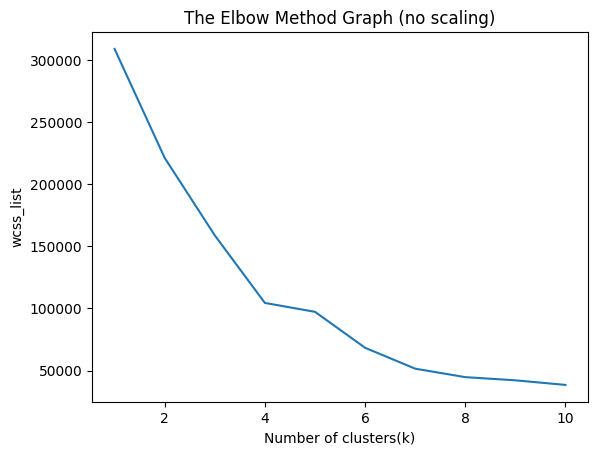

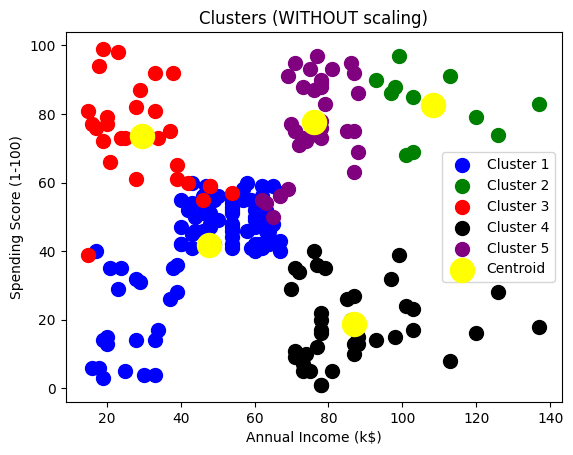

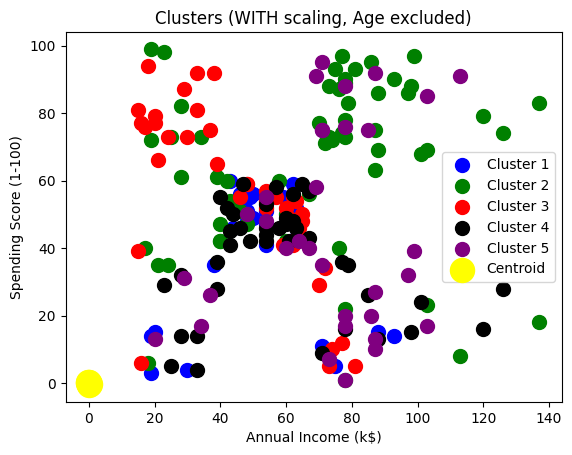

In [8]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
df.head()

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

x = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

wcss_list = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph (no scaling)')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans_no_scale = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pred_no_scale = kmeans_no_scale.fit_predict(x)

colors = ['blue', 'green', 'red', 'black', 'purple']
for i in range(5):
    mtp.scatter(x[y_pred_no_scale == i, 2], x[y_pred_no_scale == i, 3],
                s=100, c=colors[i], label=f'Cluster {i+1}')
mtp.scatter(kmeans_no_scale.cluster_centers_[:, 2],
            kmeans_no_scale.cluster_centers_[:, 3],
            s=300, c='yellow', label='Centroid')
mtp.title('Clusters (WITHOUT scaling)')
mtp.xlabel('Annual Income (k$)')
mtp.ylabel('Spending Score (1-100)')
mtp.legend()
mtp.show()
x_to_scale = df[['Gender', 'Annual Income (k$)', 'Spending Score (1-100)']].values
x_age      = df[['Age']].values                # kept as-is (not scaled)

scaler = StandardScaler()
x_scaled_part = scaler.fit_transform(x_to_scale)
import numpy as np
x_final = np.hstack([x_age, x_scaled_part])

kmeans_scaled = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pred_scaled = kmeans_scaled.fit_predict(x_final)

for i in range(5):
    mtp.scatter(x[y_pred_scaled == i, 2], x[y_pred_scaled == i, 3],
                s=100, c=colors[i], label=f'Cluster {i+1}')
mtp.scatter(kmeans_scaled.cluster_centers_[:, 1],
            kmeans_scaled.cluster_centers_[:, 2],
            s=300, c='yellow', label='Centroid')
mtp.title('Clusters (WITH scaling, Age excluded)')
mtp.xlabel('Annual Income (k$)')
mtp.ylabel('Spending Score (1-100)')
mtp.legend()
mtp.show()

# Comparison
# Without scaling: high-range features like Annual Income dominate the
# distance calculation overshadowing lower-range features like Gender.
# With scaling:each feature contributes equally, producing more
# balanced and meaningful clusters.

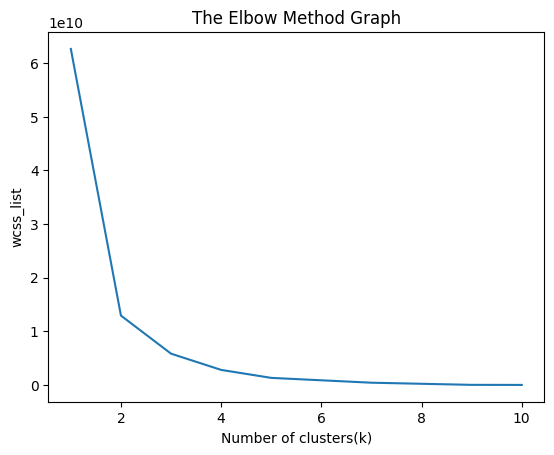

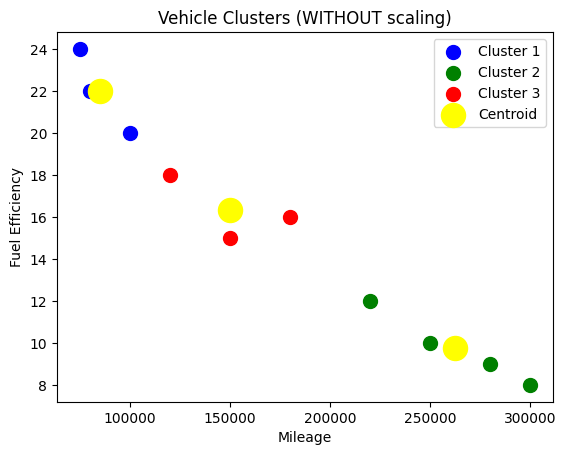

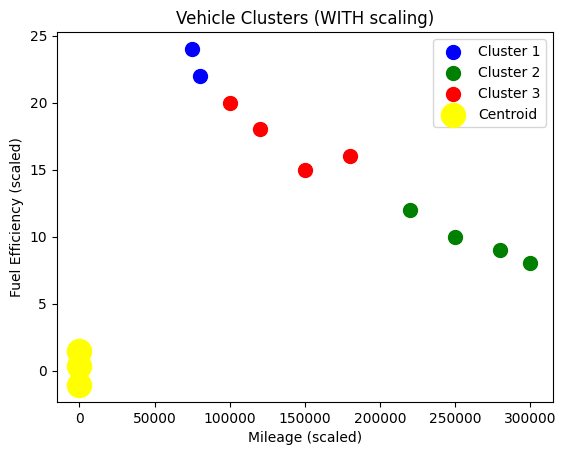

In [ ]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Sample dataset (from lab task) ---
data = {
    'vehicle_serial_no':  [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage':            [150000, 120000, 250000, 80000, 100000,
                           220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency':    [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost':   [5000, 4000, 7000, 2000, 3000,
                           6500, 5500, 8000, 1500, 7500],
    'vehicle_type':       ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan',
                           'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)
le = LabelEncoder()
df['vehicle_type_enc'] = le.fit_transform(df['vehicle_type'])

x = df[['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_enc']].values

wcss_list = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans_no_scale = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_pred_no_scale = kmeans_no_scale.fit_predict(x)

colors = ['blue', 'green', 'red']
for i in range(3):
    mtp.scatter(x[y_pred_no_scale == i, 0], x[y_pred_no_scale == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')
mtp.scatter(kmeans_no_scale.cluster_centers_[:, 0],
            kmeans_no_scale.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroid')
mtp.title('Vehicle Clusters (WITHOUT scaling)')
mtp.xlabel('Mileage')
mtp.ylabel('Fuel Efficiency')
mtp.legend()
mtp.show()

x_to_scale  = df[['mileage', 'fuel_efficiency', 'maintenance_cost']].values
x_vtype     = df[['vehicle_type_enc']].values   # not scaled (categorical)

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x_to_scale)
x_final  = np.hstack([x_scaled, x_vtype])

kmeans_scaled  = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_pred_scaled  = kmeans_scaled.fit_predict(x_final)

for i in range(3):
    mtp.scatter(x[y_pred_scaled == i, 0], x[y_pred_scaled == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')
mtp.scatter(kmeans_scaled.cluster_centers_[:, 0],
            kmeans_scaled.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroid')
mtp.title('Vehicle Clusters (WITH scaling)')
mtp.xlabel('Mileage (scaled)')
mtp.ylabel('Fuel Efficiency (scaled)')
mtp.legend()
mtp.show()

# Comparison
# Without scaling: mileage (range 75k-300k) dominates over fuel_efficiency
# (range 8-24), pulling clusters purely by distance in high-magnitude space.
# With scaling:    all three numeric features contribute equally, producing
# clusters that reflect real-world vehicle usage patterns more accurately.

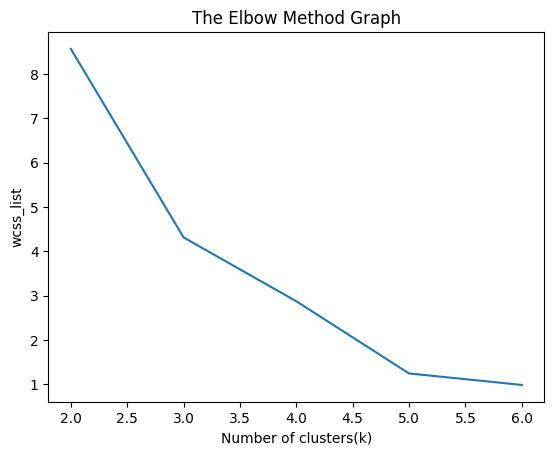

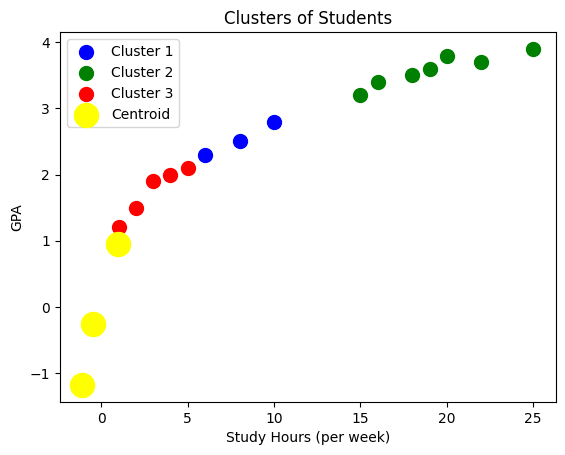

 student_id  GPA  study_hours  attendance_rate  cluster
        101  3.8           20               95        1
        102  2.1            5               60        2
        103  3.5           18               90        1
        104  1.9            3               55        2
        105  3.9           25               98        1
        106  2.5            8               70        0
        107  3.2           15               85        1
        108  1.5            2               45        2
        109  3.7           22               93        1
        110  2.8           10               75        0
        111  1.2            1               40        2
        112  3.6           19               88        1
        113  2.3            6               65        0
        114  3.4           16               87        1
        115  2.0            4               58        2


In [ ]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,111, 112, 113, 114, 115],
    'GPA':[3.8, 2.1, 3.5, 1.9, 3.9, 2.5, 3.2, 1.5, 3.7, 2.8, 1.2, 3.6, 2.3,3.4, 2.0],
    'study_hours':    [20, 5, 18, 3, 25, 8, 15, 2, 22, 10, 1, 19, 6, 16, 4],
    'attendance_rate':[95, 60, 90,55, 98, 70, 85, 45, 93, 75,40, 88,65, 87, 58]
}
df = pd.DataFrame(data)

x = df[['GPA','study_hours', 'attendance_rate']].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(x)

wcss_list = []
for i in range(2, 7):                            
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)
mtp.plot(range(2, 7), wcss_list)
mtp.title('The Elbow Method Graph')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show ()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k,init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_scaled)

df['cluster'] = y_predict

colors = ['blue', 'green', 'red']
for i in range(optimal_k):
    mtp.scatter(
        df[y_predict==i]['study_hours'],
        df[y_predict== i]['GPA'],
        s=100, c=colors[i], label=f'Cluster {i+1}'
    )
mtp.scatter(
    kmeans.cluster_centers_[:,1],  
    kmeans.cluster_centers_[:, 0],   
    s=300, c='yellow', label='Centroid'
)
mtp.title('Clusters of Students')
mtp.xlabel('Study Hours (per week)')
mtp.ylabel('GPA')
mtp.legend()
mtp.show()

print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster']].to_string(index=False))